In [1]:
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np

from pybaselines import Baseline, utils

import lmfit as lm
from lmfit import Model, Parameters, Parameter, report_fit, minimize, Minimizer

from scipy.signal import find_peaks

from assign_peaks import *

In [2]:
InputFile = 'co2_gasmas/C1(2f)_2023_05_31_17-55.txt'
Dataset = np.loadtxt(InputFile, skiprows= 5, delimiter=',')
raw_x = Dataset[:, 0]
raw_y = Dataset[:, 1]

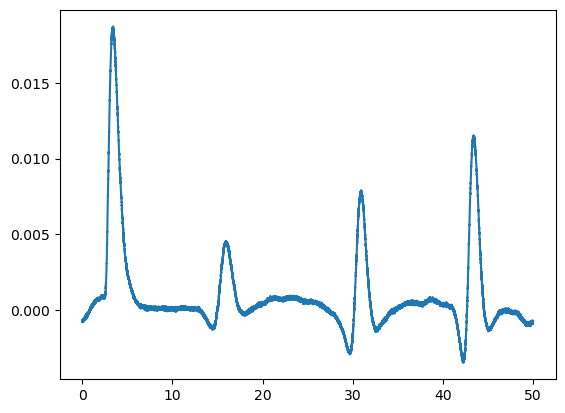

In [3]:
plt.plot(raw_x, raw_y)

In [4]:
#Number_of_Samples_per_Second
SpS = int(len(raw_x)/np.max(raw_x))
print("!Sampling rate of the datases is " + str(SpS) + " Samples/s!" )

!Sampling rate of the datases is 500 Samples/s!


In [5]:
Dataset = np.loadtxt(InputFile, skiprows= 5, delimiter=',')
x = Dataset[4000:24000, 0]
y = Dataset[4000:24000, 1]

In [6]:
Out1 = PdfPages('out2f_exp.pdf')
Out2 = PdfPages('out2f_fit.pdf')

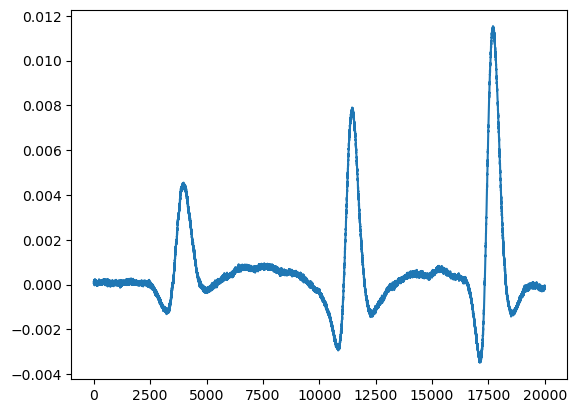

In [7]:
plt.plot(y)

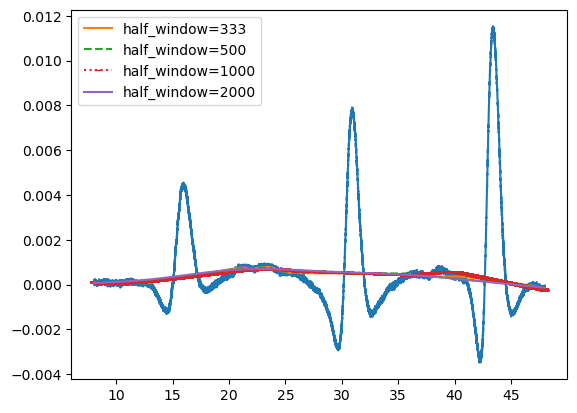

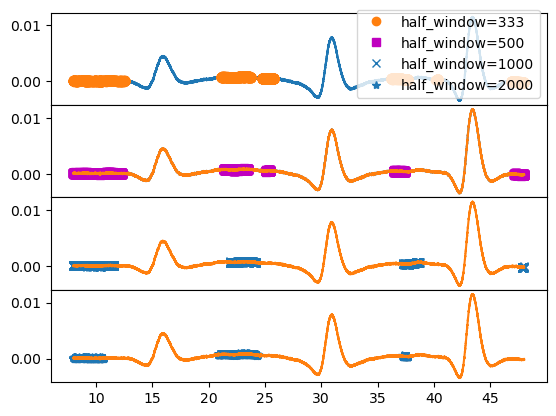

In [8]:
baseline_fitter = Baseline(x_data=x)

#std_distribution(data, x_data=None, half_window=None, interp_half_window=5,
#                     fill_half_window=3, num_std=1.1, smooth_half_window=None,
#                     weights=None, **pad_kwargs):

half_window_1 = 333
half_window_2 = 500
half_window_3 = 1000
half_window_4 = 2000


fit_1, params_1 = baseline_fitter.std_distribution(y, half_window_1, smooth_half_window=None)
fit_2, params_2 = baseline_fitter.std_distribution(y, half_window_2, smooth_half_window=None)
fit_3, params_3 = baseline_fitter.std_distribution(y, half_window_3, smooth_half_window=None)
fit_4, params_4 = baseline_fitter.std_distribution(y, half_window_4, smooth_half_window=None)


plt.plot(x, y)
plt.plot(x, fit_1, label=f'half_window={half_window_1}')
plt.plot(x, fit_2, '--', label=f'half_window={half_window_2}')
plt.plot(x, fit_3, '_:',  label=f'half_window={half_window_3}')
plt.plot(x, fit_4, '-', label=f'half_window={half_window_4}')
plt.legend()

mask_1 = params_1['mask']
mask_2 = params_2['mask']
mask_3 = params_3['mask']
mask_4 = params_4['mask']

_, (ax1, ax2, ax3, ax4) = plt.subplots(4, sharex=True, gridspec_kw={'hspace': 0})
ax1.plot(x, y)
patch_1 = ax1.plot(x[mask_1], y[mask_1], 'o')[0]
ax2.plot(x, y)
patch_2 = ax2.plot(x[mask_2], y[mask_2], 'ms')[0]
ax2.plot(x, y)
patch_3 = ax3.plot(x[mask_3], y[mask_3], 'x')[0]
ax3.plot(x, y)
patch_4 = ax4.plot(x[mask_4], y[mask_4], '*')[0]
ax4.plot(x, y)

ax1.legend((patch_1, patch_2, patch_3, patch_4), (f'half_window={half_window_1}', f'half_window={half_window_2}', f'half_window={half_window_3}', f'half_window={half_window_4}'))

plt.show()

@_classification_wrapper
def std_distribution(data, x_data=None, half_window=None, interp_half_window=5,
                     fill_half_window=3, num_std=1.1, smooth_half_window=None,
                     weights=None, **pad_kwargs):
    """
    Identifies baseline segments by analyzing the rolling standard deviation distribution.

    The rolling standard deviations are split into two distributions, with the smaller
    distribution assigned to noise. Baseline points are then identified as any point
    where the rolling standard deviation is less than a multiple of the median of the
    noise's standard deviation distribution.

    Parameters
    ----------
    data : array-like, shape (N,)
        The y-values of the measured data, with N data points.
    x_data : array-like, shape (N,), optional
        The x-values of the measured data. Default is None, which will create an
        array from -1 to 1 with N points.
    half_window : int, optional
        The half-window to use for the rolling standard deviation calculation. Should
        be approximately equal to the full-width-at-half-maximum of the peaks or features
        in the data. Default is None, which will use half of the value from
        :func:`.optimize_window`, which is not always a good value, but at least scales
        with the number of data points and gives a starting point for tuning the parameter.
    interp_half_window : int, optional
        When interpolating between baseline segments, will use the average of
        ``data[i-interp_half_window:i+interp_half_window+1]``, where `i` is
        the index of the peak start or end, to fit the linear segment. Default is 5.
    fill_half_window : int, optional
        When a point is identified as a peak point, all points +- `fill_half_window`
        are likewise set as peak points. Default is 3.
    num_std : float, optional
        The number of standard deviations to include when thresholding. Higher values
        will assign more points as baseline. Default is 1.1.
    smooth_half_window : int, optional
        The half window to use for smoothing the interpolated baseline with a moving average.
        Default is None, which will use `half_window`. Set to 0 to not smooth the baseline.
    weights : array-like, shape (N,), optional
        The weighting array, used to override the function's baseline identification
        to designate peak points. Only elements with 0 or False values will have
        an effect; all non-zero values are considered baseline points. If None
        (default), then will be an array with size equal to N and all values set to 1.
    **pad_kwargs
        Additional keyword arguments to pass to :func:`.pad_edges` for padding
        the edges of the data to prevent edge effects from the moving average smoothing.
        
    Returns
    -------
    baseline : numpy.ndarray, shape (N,)
        The calculated baseline.
    params : dict
        A dictionary with the following items:

        * 'mask': numpy.ndarray, shape (N,)
            The boolean array designating baseline points as True and peak points
            as False.

    References
    ----------
    Wang, K.C., et al. Distribution-Based Classification Method for Baseline
    Correction of Metabolomic 1D Proton Nuclear Magnetic Resonance Spectra.
    Analytical Chemistry. 2013, 85, 1231-1239.

    """

In [9]:
print(len(fit_1))
print(len(y))
print(len(y-fit_1))

y=y-fit_1

20000
20000
20000


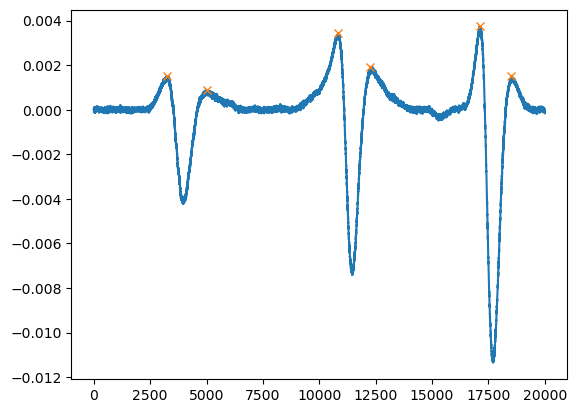

In [10]:
valleys, _ = find_peaks(-y, height=0, distance=500, width=250)
np.diff(valleys)
plt.plot(-y)
plt.plot(valleys, -y[valleys], "x")
plt.show()

xval = x[valleys]
yval = y[valleys]

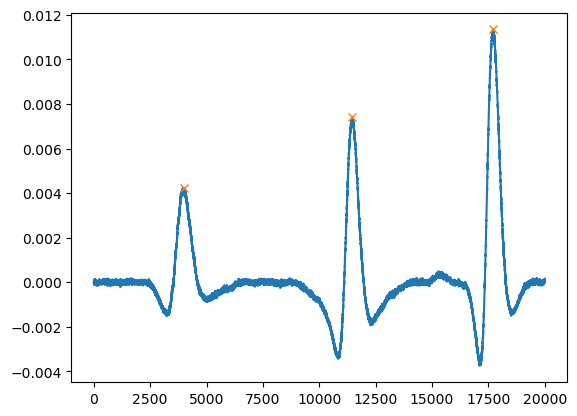

In [11]:
peaks, _ = find_peaks(y, height=0.001, distance=2500, width=500)
np.diff(peaks)
plt.plot(y)
plt.plot(peaks, y[peaks], "x")
plt.show()

xpik = x[peaks]
ypik = y[peaks]

In [12]:
#vytvoreni pole objektu peaku
peak_objects = AssignPeaks(xpik, xval, ypik, yval)
numpeak = len(peak_objects)
#overeni delek poli minim a maxim
VerifyPeaksLength(xpik, xval, peak_objects)
#vypsat
SavePeakSpectra(peak_objects, x, y, InputFile, 2)

Peaks matched/consistent definition!
Total number of peaks identified in 2f-WMS signal is: 3
Peak1 centered at: 15.964(left minimum: 14.452; right minimum: 18.062)
Peak2 centered at: 30.916(left minimum: 29.68; right minimum: 32.536)
Peak3 centered at: 43.42(left minimum: 42.234; right minimum: 45.014)


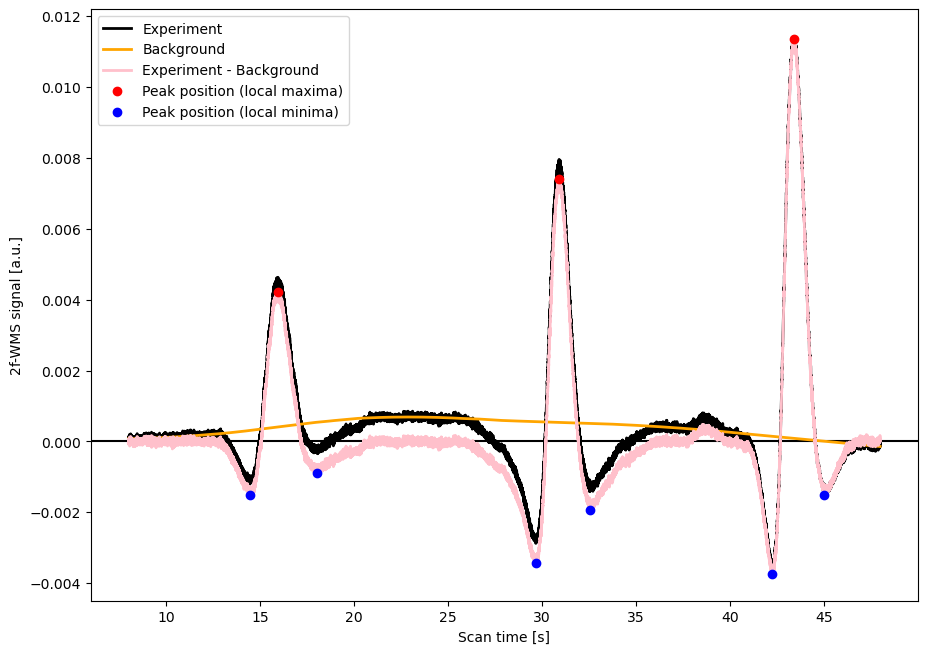

In [13]:
plt.figure(1)

plt.axhline(0, color='black')
line1, = plt.plot(x, y+fit_4, 'black', linewidth=2, label='Experiment')
line2, = plt.plot(x, fit_4, 'orange', linewidth=2, label='Background')
line3, = plt.plot(x, y, 'pink', linewidth=2, label='Experiment - Background')

point1, = plt.plot(xpik, ypik, 'ro', linewidth=2, label='Peak position (local maxima)')
point2, = plt.plot(xval, yval, 'bo', linewidth=2, label='Peak position (local minima)')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
plt.xlabel(r"Scan time [s]")
plt.ylabel(r"2f-WMS signal [a.u.]")

plt.tight_layout()
a4 = plt.gcf()
a4.set_size_inches([10,7])
a4.savefig(Out1, format='pdf')
plt.show()

Out1.close()

In [14]:
def lorentzianA(x, a0, a1, a2):
    return a0/(np.pi*a2*(1+((x-a1)/a2)**2))

def D2lorentzianA(x, a0, a1, a2):
    return -2*a0*a2*(a2**2-3*(a1-x)**2)/(np.pi*(a2**2+(a1-x)**2)**3)

def gaussianA(x, a0, a1, a2):
    sigma = a2/np.sqrt(2*np.log(2))
    return a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*sigma**2))

def D2gaussianA(x, a0, a1, a2):
    sigma = np.sqrt(2*np.log(2))*a2
    poly2 = ((x-a1)**2-sigma**2)/sigma**4
    return poly2*a0/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*sigma**2))

In [15]:
result=[None]*numpeak
par=[None]*numpeak
resdata=[None]*numpeak
ofst=[None]*numpeak
minner=[None]*numpeak
res2ult=[None]*numpeak
fin2ual=[None]*numpeak
res2data=[None]*numpeak
par2am=[None]*numpeak
gabor2=[None]*numpeak
gabor4=[None]*numpeak
gabor6=[None]*numpeak
gabor8=[None]*numpeak

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1108
    # data points      = 7606
    # variables        = 3
    chi-square         = 3.7434e-04
    reduced chi-square = 4.9235e-08
    Akaike info crit   = -127980.527
    Bayesian info crit = -127959.717
    R-squared          = 0.95873580
[[Variables]]
    a0: -0.03589663 +/- 2.0599e-04 (0.57%) (init = 0.004223182)
    a1:  16.0457690 +/- 0.00155713 (0.01%) (init = 8.662)
    a2:  1.77152401 +/- 0.00369953 (0.21%) (init = 3.042)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.9111
    C(a1, a2) = +0.1630
    C(a0, a1) = -0.1485
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 703
    # data points      = 7606
    # variables        = 11
    chi-square         = 1.0017e-04
    reduced chi-square = 1.3189e-08
    Akaike info crit   = -137991.478
    Bayesian info crit = -137915.174
##  Warning: uncertainties could not be estimated:
    k6:

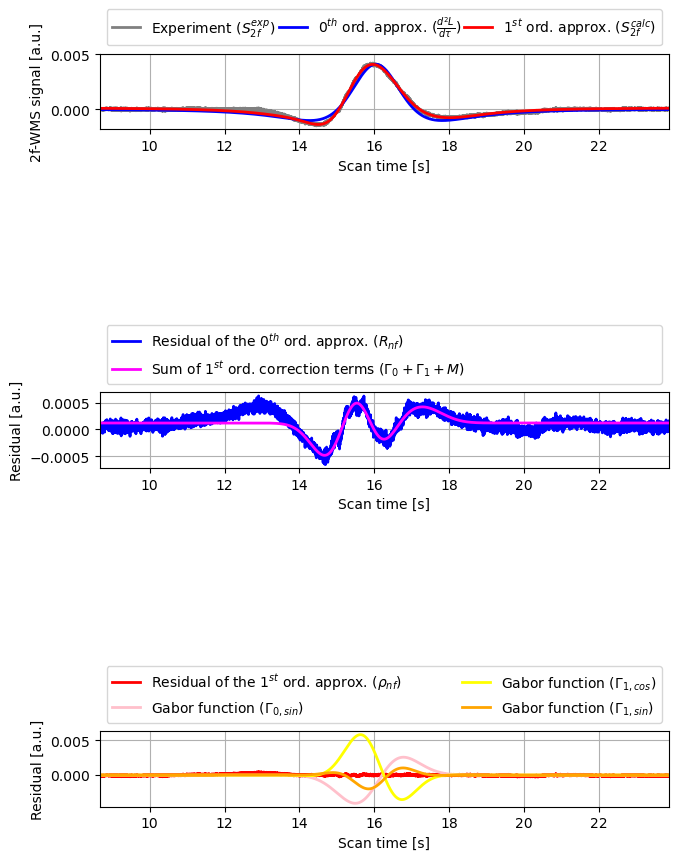

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1390
    # data points      = 6269
    # variables        = 3
    chi-square         = 0.00119623
    reduced chi-square = 1.9091e-07
    Akaike info crit   = -96987.6732
    Bayesian info crit = -96967.4431
    R-squared          = 0.95665450
[[Variables]]
    a0: -0.03970833 +/- 2.5261e-04 (0.64%) (init = 0.007418852)
    a1:  30.9991573 +/- 0.00149187 (0.00%) (init = 24.85)
    a2:  1.48017521 +/- 0.00341423 (0.23%) (init = 2.5072)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.9066
    C(a1, a2) = +0.1853
    C(a0, a1) = -0.1680
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 475
    # data points      = 6269
    # variables        = 11
    chi-square         = 1.0679e-04
    reduced chi-square = 1.7065e-08
    Akaike info crit   = -112117.988
    Bayesian info crit = -112043.811
##  Warning: uncertainties could not be estimated:
[[Vari

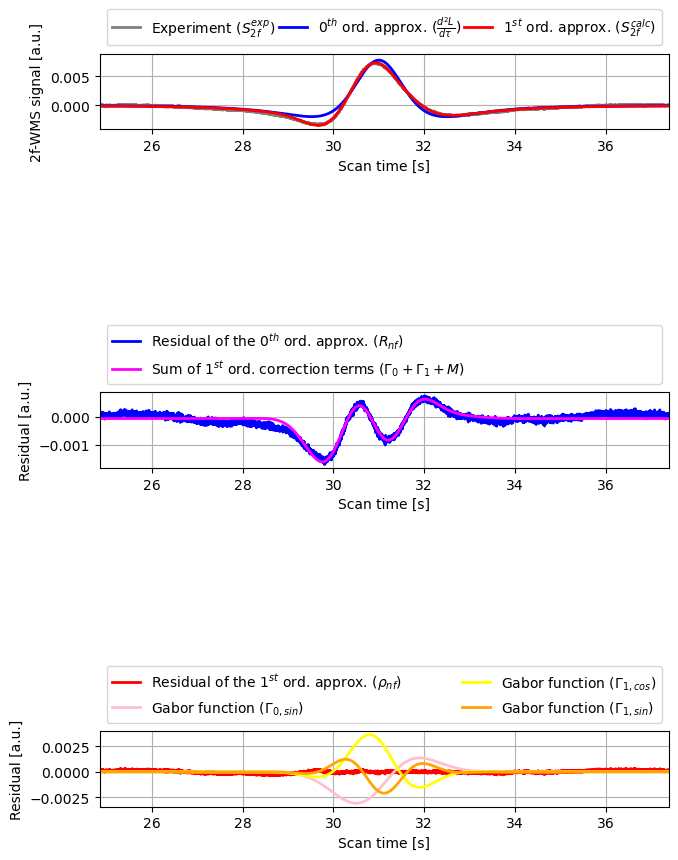

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1292
    # data points      = 4365
    # variables        = 3
    chi-square         = 0.00405826
    reduced chi-square = 9.3037e-07
    Akaike info crit   = -60616.7575
    Bayesian info crit = -60597.6134
    R-squared          = 0.92176823
[[Variables]]
    a0: -0.05324403 +/- 5.6994e-04 (1.07%) (init = 0.01134476)
    a1:  43.5042847 +/- 0.00233604 (0.01%) (init = 39.27)
    a2:  1.46177136 +/- 0.00572683 (0.39%) (init = 1.7456)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.9163
    C(a1, a2) = +0.2022
    C(a0, a1) = -0.1852
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 587
    # data points      = 4365
    # variables        = 11
    chi-square         = 2.3033e-04
    reduced chi-square = 5.2902e-08
    Akaike info crit   = -73123.8359
    Bayesian info crit = -73053.6408
##  Warning: uncertainties could not be estimated:
[[Varia

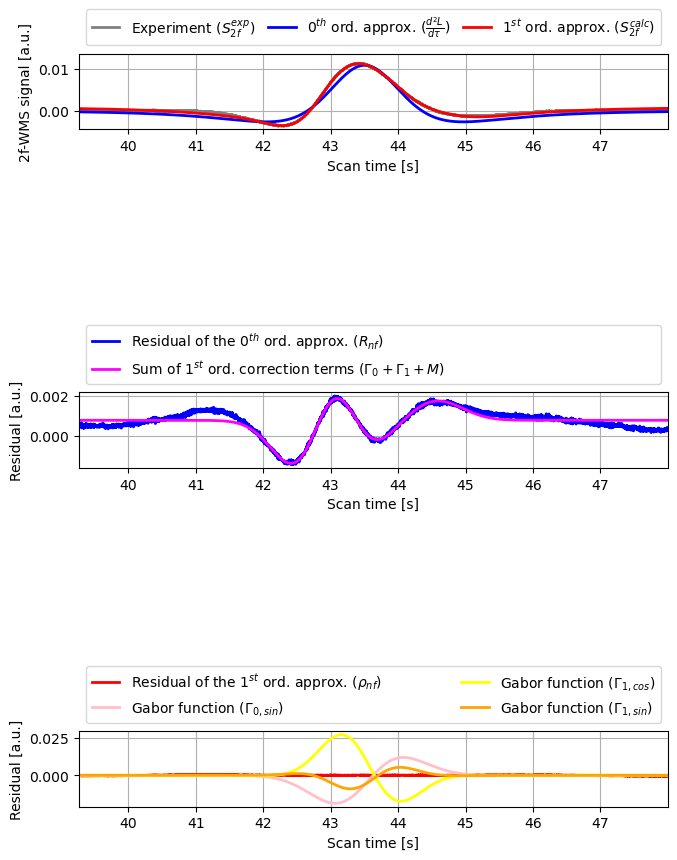

In [16]:
for i in range(1,numpeak+1):
    j=i-1
    
    InputFilePeaks = InputFile.replace(".txt", '_Peak') + str(i) + '.txt'
    Dataset = np.loadtxt(InputFilePeaks, skiprows= 0 + 1 + 2 + 3 + 4 , delimiter=',')
    x = Dataset[:, 0]
    y = Dataset[:, 1]

    Out3i = PdfPages('out_peakfit' + str(i) + '.pdf')
    
    params = lm.Parameters()
    params.add('a0', value=np.maximum(np.abs(np.amax(-y)),np.abs(np.amin(-y))), min=10*np.amin(-y), max=10*np.amax(-y))
    params.add('a1', value=np.amin(x)-(np.amax(x)-np.amin(x))/2, min=np.amin(x), max=np.amax(x))
    params.add('a2', value=(np.amax(x)-np.amin(x))/5, min=(np.amax(x)-np.amin(x))/10, max=(np.amax(x)-np.amin(x))/2)

    #model = lm.Model(D2gaussianA)
    model = lm.Model(D2lorentzianA)
     #result[j] = model.fit(y, params, x=x, method='leastsq')
    result[j] = model.fit(y, params, x=x, method='differential_evolution')
    
    lm.report_fit(result[j])

    par[j] = result[j].best_values
   
    resdata[j] = result[j].residual
    
    ofst[j] = np.mean(resdata[j])
    
    def residual(params, x, resdata):
        "Gabor polynomial"
        params['a0']= Parameter(name = 'a0', value = par[j]['a0'] , vary = False)
        params['a1']= Parameter(name = 'a1', value = par[j]['a1'] , vary = False)
        params['a2']= Parameter(name = 'a2', value = par[j]['a2'] , vary = False)

        off = params['off']
        params['off']= Parameter(name = 'off', value = ofst[j] , vary = False)
        k2 = params['k2']
        k4 = params['k4']
        k6 = params['k6']

        #k8 = params['k8']
        #fi8 = params['fi8']

        fi6 = params['fi6']
        fi4 = params['fi4']
        fi2 = params['fi2']
        
        a0 = params['a0']
        a1 = params['a1']
        a2 = params['a2']

        w = params['w']

        sigma = a2/np.sqrt(2*np.log(2))
        #gabor8 = np.cos(2*np.pi*(0/2)*(x-a1)/(2*a2)+fi8)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor6 = np.sin(2*np.pi*(3/2)*(x-a1)/(2*a2)+fi6)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor4 = np.cos(2*np.pi*(2/2)*(x-a1)/(2*a2)+fi4)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor2 = np.sin(2*np.pi*(1/2)*(x-a1)/(2*a2)+fi2)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        
        #return off + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        return off + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
    
        # create a set of Parameters
    
    params.add('off', min=0, max=par[j]['a0'])
    params.add('k6', value=1.0, min=0.1, max=20.0, vary = True)
    params.add('k4', value=1.0, min=0.1, max=20.0, vary = True)
    params.add('k2', value=1.0, min=0.1, max=20.0, vary = True)
    #params.add('k8', value=1.0, min=-2.5, max=+2.5, vary = True)
    #params.add('fi8', value=0.0, min=-np.pi, max=np.pi, vary = False)
    params.add('fi6', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi4', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi2', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('w', value=1, min=1/3, max=4/3, vary = True)

       
    # do fit, here with leastsq model
    minner[j] = Minimizer(residual, params, fcn_args=(x, resdata[j]))
    res2ult[j] = minner[j].minimize(method = 'leastsq')
    # res2ult[j] = minner[j].minimize(method = 'differential_evolution')

    par2am[j] = res2ult[j].params
    #par2am[j].pretty_print()

    offj=par2am[j]['off'].value
    a0j=par2am[j]['a0'].value
    a1j=par2am[j]['a1'].value
    a2j=par2am[j]['a2'].value
    k6j=par2am[j]['k6'].value
    k4j=par2am[j]['k4'].value
    k2j=par2am[j]['k2'].value
    #k8j=par2am[j]['k8'].value
    #fi8j=par2am[j]['fi8'].value
    fi6j=par2am[j]['fi6'].value
    fi4j=par2am[j]['fi4'].value
    fi2j=par2am[j]['fi2'].value
    sigmaj = a2j/np.sqrt(2*np.log(2))
    wj=par2am[j]['w'].value

    #gabor8[j] = np.cos(0*np.pi*(x-a1j)/(2*a2j)+fi8j)*k8j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor6[j] = np.sin(3*np.pi*(x-a1j)/(2*a2j)+fi6j)*k6j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor4[j] = np.cos(2*np.pi*(x-a1j)/(2*a2j)+fi4j)*k4j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor2[j] = np.sin(1*np.pi*(x-a1j)/(2*a2j)+fi2j)*k2j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))

    res2data[j] = res2ult[j].residual
    
    # calculate final result
    fin2ual[j] = resdata[j] + res2data[j]
    
    # write error report
    report_fit(res2ult[j])
    
    fig2 = plt.figure(2)
    
    ax1=plt.subplot(311)
    line2, = plt.plot(x, y, 'grey', linewidth=2, label= r'Experiment ($S_{2f}^{exp}$)')
    line3, = plt.plot(x, result[j].best_fit, 'blue', linewidth=2, label= r'$0^{th}$ ord. approx. ($\frac{d^{2}L}{d\tau}$)')
    line3f, = plt.plot(x, result[j].best_fit-fin2ual[j], 'red', linewidth=2, label= r'$1^{st}$ ord. approx. ($S_{2f}^{calc}$)')
    plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=3)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"2f-WMS signal [a.u.]")
    plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 1.2*np.amin(y), 1.2*np.amax(y),])
    plt.grid(True)

    ax2=plt.subplot(312, sharex=ax1)
    line4, = plt.plot(x, -result[j].residual, 'blue',linewidth=2, label=r'Residual of the $0^{th}$ ord. approx. ($R_{nf}$)')
    line5, = plt.plot(x, -fin2ual[j], 'magenta', linewidth=2, label=r'Sum of $1^{st}$ ord. correction terms ($\Gamma_0 + \Gamma_1 + M$)')
    plt.legend(handler_map={line4: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), -1.5*np.amax(result[j].residual), -2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    ax3=plt.subplot(313, sharex=ax1)
    line6, = plt.plot(x, res2ult[j].residual, 'red',linewidth=2, label=r'Residual of the $1^{st}$ ord. approx. ($\rho_{nf}$)')
    line7, = plt.plot(x, -gabor2[j], 'pink',linewidth=2, label= r'Gabor function ($\Gamma_{0,sin}$)')
    line8, = plt.plot(x, -gabor4[j], 'yellow',linewidth=2, label= r'Gabor function ($\Gamma_{1,cos}$)')
    line9, = plt.plot(x, -gabor6[j], 'orange',linewidth=2, label=r'Gabor function ($\Gamma_{1,sin}$)')
    #line10, = plt.plot(x, gabor8[j], 'cyan',linewidth=2, label='Gabor function (n=8)')
    #line11, = plt.plot(x, -gabor2[j]-gabor4[j]-gabor6[j]-gabor8[j], 'm:',linewidth=4)
    plt.legend(handler_map={line6: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=2)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 2.0*offj-1.5*np.amax(result[j].residual), 2.0*offj-2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    plt.tight_layout()
    a4 = plt.gcf()
    a4.set_size_inches([7,10])
    a4.savefig(Out2, format='pdf')
    a4.savefig(Out3i, format='pdf')
    plt.show()

    Out3i.close()
    
Out2.close()